# Examen visión computacional
---
## Ricardo Alfredo Calvo Pérez - A01028889

## Instrucciones
---

1. Revisa el dataset que se incluye en las celdas siguientes.
2. En base a este, crea un clasificador que pueda decir el tipo de coche y su color.
3. Llena las celdas de código como se va solicitando.
4. Al terminar, sube el notebook con todas las celdas ejecutadas a canvas.

## Imports

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install numpy pandas matplotlib opencv-python pillow lightning torchmetrics scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (2449.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-win_amd64.whl (6.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (4.1 MB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
     ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
     ---------------------------------------- 536.2/536.2 kB 8.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   --------------- ------------------------ 2.6/7.0 MB 13.7 MB/s eta 0:00:01
   ------------------------------ --------- 5.2/7.0 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 12.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:

In [ ]:
import numpy as np
import pandas as pd
import cv2
import os

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Subset

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import torchvision
import torchmetrics
from torchvision import transforms
from torchvision import models
from torchvision.datasets import ImageFolder

from PIL import Image

import matplotlib.pyplot as plt

## Descarga del dataset

In [3]:
!rm -r cars
!rm cars_multilabel.zip
!curl -L -o ./cars_multilabel.zip https://www.kaggle.com/api/v1/datasets/download/julichitai/multilabel-small-car-and-color-dataset
!unzip -d cars cars_multilabel.zip > /dev/null

"rm" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"rm" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0  240M    0 76574    0     0   169k      0  0:24:17 --:--:--  0:24:17  169k
  4  240M    4 12.0M    0     0  8570k      0  0:00:28  0:00:01  0:00:27 12.0M
  9  240M    9 23.5M    0     0  9871k      0  0:00:24  0:00:02  0:00:22 11.7M
 15  240M   15 36.1M    0     0  10.5M      0  0:00:22  0:00:03  0:00:19 12.0M
 19  240M   19 47.6M    0     0  10.7M      0  0:00:22  0:00:04  0:00:18 11.9M
 24  240M   24 59.8M    0     0  11.0M      0  0:00:21  0:00:05  0:00:16 11.9M
 29  240M   29 7

In [4]:
!ls cars

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Visualización de imágenes **(5 puntos)**
---

**TO DO**: Visualiza una imagen de cada clase.

In [ ]:
base_path = os.getenv("COMP_VISION_PATH")

dataset_root = os.path.join(base_path, "cars_multilabel")
dataset = ImageFolder(root=dataset_root)

classes = dataset.classes
class_to_idx = dataset.class_to_idx

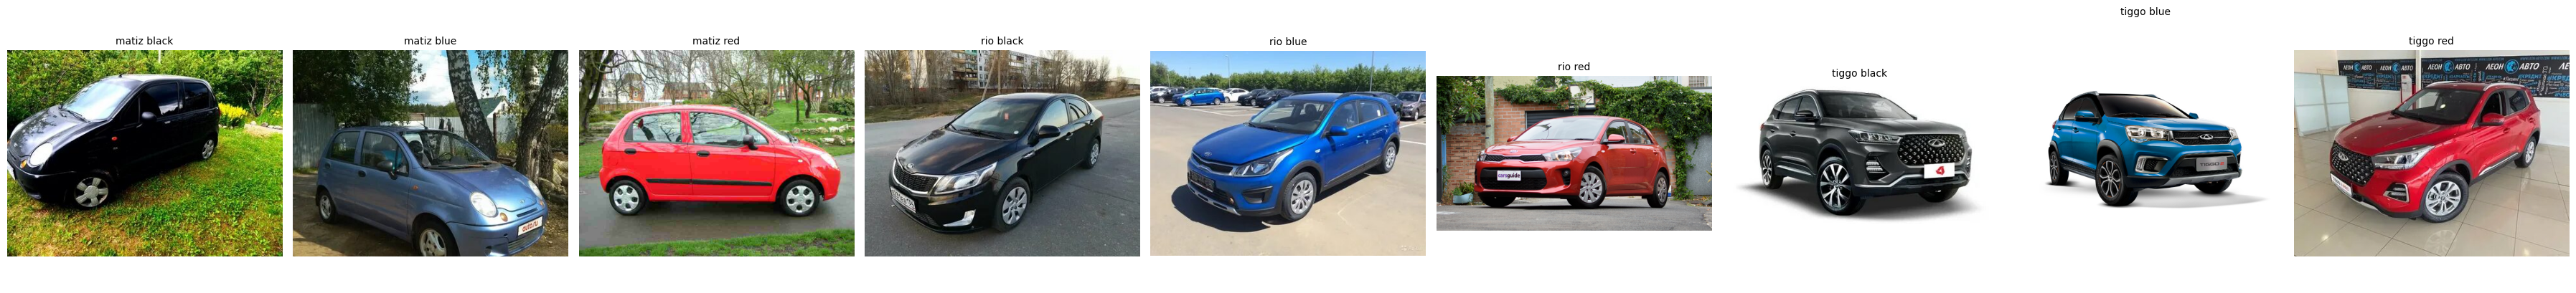

In [ ]:
num_classes = len(classes)

fig, axes = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))

if num_classes == 1:
    axes = [axes]

for i, class_name in enumerate(classes):
    class_idx = class_to_idx[class_name]

    indices = [j for j, (_, y) in enumerate(dataset) if y == class_idx]

    rand_idx = np.random.choice(indices)

    image, label = dataset[rand_idx]

    ax = axes[i]
    ax.imshow(image)
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Carga de imágenes en dataloaders **(15 puntos)**
---

**TO DO**: Construye los dataloaders necesarios, con las transformaciónes adecuadas, y muestra un batch. Connstruye las etiquetas de las imágenes para poder hacer clasificación multi-etiqueta.

In [35]:
image_transforms = transforms.Compose([

        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.25),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),

])


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


In [ ]:
dataset = ImageFolder(root=dataset_root)
n_total = len(dataset)

train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

train_size = int(train_ratio * n_total)
val_size   = int(val_ratio * n_total)
test_size  = n_total - train_size - val_size

g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator=g)

train_idx = perm[:train_size]
val_idx   = perm[train_size:train_size + val_size]
test_idx  = perm[train_size + val_size:]

train = ImageFolder(root=dataset_root, transform=image_transforms)
val = ImageFolder(root=dataset_root, transform=test_transforms)
test = ImageFolder(root=dataset_root, transform=test_transforms)

train_dataset = Subset(train, train_idx)
val_dataset   = Subset(val,   val_idx)
test_dataset  = Subset(test,  test_idx)

train_dataloader = DataLoader(train_dataset, batch_size=25, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=25, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=25, shuffle=False)


## Definición del modelo **(15 puntos)**
---

**TO DO**: Crea un modelo con capas convolucionales para hacer la clasificación.

In [37]:
resnet_model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, num_classes)


class CnnModel(L.LightningModule):
    def __init__(self, model, learning_rate, num_classes):
        super().__init__()

        self.learning_rate = learning_rate
        self.model = model

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc  = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        features, true_labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, true_labels)

        return loss, logits, true_labels

    def training_step(self, batch, batch_idx):
        loss, logits, true_labels = self._shared_step(batch)

        self.log("train_loss", loss)
        self.train_acc(logits, true_labels)
        self.log("train_acc", self.train_acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, logits, true_labels = self._shared_step(batch)

        self.log("val_loss", loss, prog_bar=True)
        self.val_acc(logits, true_labels)
        self.log("val_acc", self.val_acc, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        with torch.no_grad():
            loss, logits, true_labels = self._shared_step(batch)
            self.test_acc(logits, true_labels)
            self.log("test_acc", self.test_acc)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer


## Entrenamiento **(5 puntos)**
---

**TO DO**: Entrena el modelo, y muestra los resultados de validación y entrenamiento.

In [38]:
car_classifier = CnnModel(
    model=resnet_model,
    learning_rate=1e-4,
    num_classes=num_classes
)

best_model_checkpoint = ModelCheckpoint(
    dirpath="checkpoints/",
    filename="car_classifier_best",
    save_top_k=1,
    monitor="val_loss",
    mode="min"
)

car_trainer = L.Trainer(
    accelerator="gpu",
    max_epochs=15,
    logger=CSVLogger(save_dir="logs/", name="car_classifier"),
    callbacks=[best_model_checkpoint]
)

car_trainer.fit(
    model=car_classifier,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
f:\TEC\Septimo\TC3007C\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory F:\TEC\Septimo\TC3007C\ComputerVision\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model     | ResNet             | 58.2 M | train | 0    
1 | train_acc | MulticlassAccuracy | 0      | train | 0    
2 | val_acc   | MulticlassAccuracy | 0      | train | 0    
3 | test_acc  | MulticlassAccuracy | 0      | train | 0    
-----------------------------------------------------------------
58.2 M    Trainable params
0         Non-trainable params
58.2 M    Total params
232.649   Total estimated model params size (MB)
426       Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

f:\TEC\Septimo\TC3007C\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


f:\TEC\Septimo\TC3007C\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 14: 100%|██████████| 74/74 [00:32<00:00,  2.30it/s, v_num=3, val_loss=0.163, val_acc=0.959, train_acc=0.987]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 74/74 [00:32<00:00,  2.30it/s, v_num=3, val_loss=0.163, val_acc=0.959, train_acc=0.987]


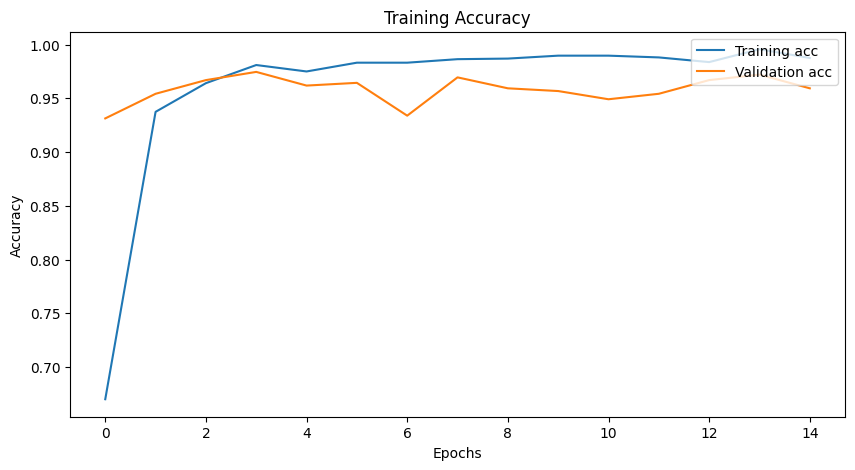

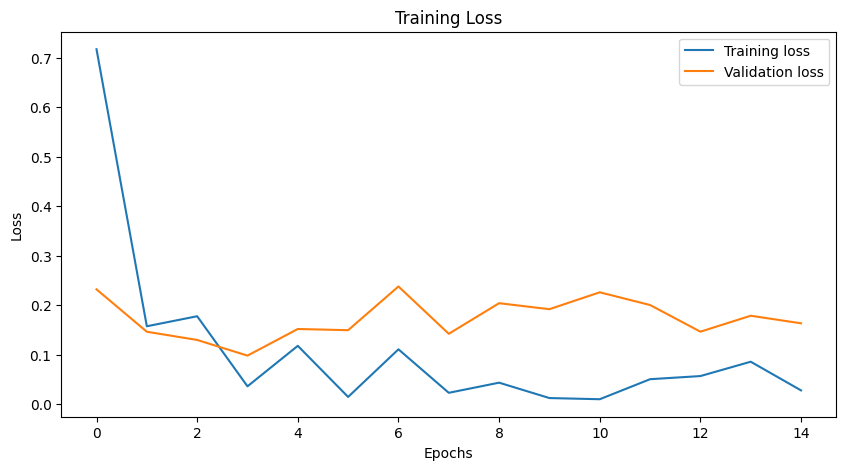

In [39]:
# Read the metrics.csv file generated by the PyTorch Lightning logger
metrics = pd.read_csv(f"{car_trainer.logger.log_dir}/metrics.csv")
# Group the metrics by epoch and compute the mean loss for each epoch
df_epochs = metrics.groupby('epoch').mean()

# Create a figure and axis for plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# Set the x-axis label
ax.set_xlabel('Epochs')
# Set the y-axis label
ax.set_ylabel('Accuracy')
# Plot the training loss over epochs
ax.plot(df_epochs['train_acc'], label="Training acc")
# Plot the validation loss over epochs
ax.plot(df_epochs['val_acc'], label="Validation acc")
# Set the title of the plot
ax.set_title("Training Accuracy")
# Add a legend to the plot
ax.legend(loc='upper right')



# Create a figure and axis for plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# Set the x-axis label
ax.set_xlabel('Epochs')
# Set the y-axis label
ax.set_ylabel('Loss')
# Plot the training loss over epochs
ax.plot(df_epochs['train_loss'], label="Training loss")
# Plot the validation loss over epochs
ax.plot(df_epochs['val_loss'], label="Validation loss")
# Set the title of the plot
ax.set_title("Training Loss")
# Add a legend to the plot
ax.legend(loc='upper right')

## Pruebas **(5 puntos)**
---

**TO DO**: Prueba el desempeño de tu modelo con datos de prueba.

In [40]:
def compute_accuracy(model, dataloader, device=None):
    """Compute the accuracy of the model on the given dataloader."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval()

    correct = 0
    total_examples = 0

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels   = labels.to(device)

            logits = model(features)
            predictions = torch.argmax(logits, dim=1)

            compare = (labels == predictions)
            correct += compare.sum().item()
            total_examples += labels.size(0)

    return correct / total_examples


In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_acc = compute_accuracy(car_classifier, train_dataloader, device)
val_acc   = compute_accuracy(car_classifier, val_dataloader, device)
test_acc  = compute_accuracy(car_classifier, test_dataloader, device)

print(
    f"Train Acc {train_acc*100:.2f}%",
    f" | Val Acc {val_acc*100:.2f}%",
    f" | Test Acc {test_acc*100:.2f}%"
)


Train Acc 99.67%  | Val Acc 95.93%  | Test Acc 96.71%


## Predicción **(5 puntos)**
---

**TO DO**: Descarga una imagen, y haz una predicción sobre ella. Usa wget como en el siguiente ejemplo.

In [68]:
!curl -L -o  matiz_rojo.jpg https://i.pinimg.com/736x/83/90/e7/8390e7fb457d2b87f98483982ebe4a62.jpg
!curl -L -o matiz_azul.jpg https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS5PLjk1Jjf815mp_I1GabqD16uV1KXdVPPRw
!curl -L -o matiz_negro.jpg https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQREmMNufmUUiHSTCjCe7zoxiL04o11phfc-w&s
!curl -L -o tiggo_negro.jpg https://images.prd.kavak.io/eyJidWNrZXQiOiJrYXZhay1pbWFnZXMiLCJrZXkiOiJpbWFnZXMvNDUyNjUxL0VYVEVSSU9SLWZyb250U2lkZVBpbG90TmVhci0xNzU5NjI3ODExODEzLmpwZWciLCJlZGl0cyI6eyJyZXNpemUiOnsid2lkdGgiOjU0MCwiaGVpZ2h0IjozMTAsImJhY2tncm91bmQiOnsiciI6MjU1LCJnIjoyNTUsImIiOjI1NSwiYWxwaGEiOjB9fX19
!curl -L -o tiggo_rojo.jpg https://d16b8fnjzv0ami.cloudfront.net/media/media/color_car/2025/10/08/Tiggo-4-com-Rojo-Agata.png
!curl -L -o rio_azul.jpg https://i.pinimg.com/736x/ba/b7/b7/bab7b72758e1799f121a878154a05e7a.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 44979  100 44979    0     0   440k      0 --:--:-- --:--:-- --:--:--  448k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  9028  100  9028    0     0   122k      0 --:--:-- --:--:-- --:--:--  125k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  9204  100  9204    0     0   126k      0 --:--:-- --:--:-- --:--:--  130k
"s" no se reconoce como un comando interno o exte

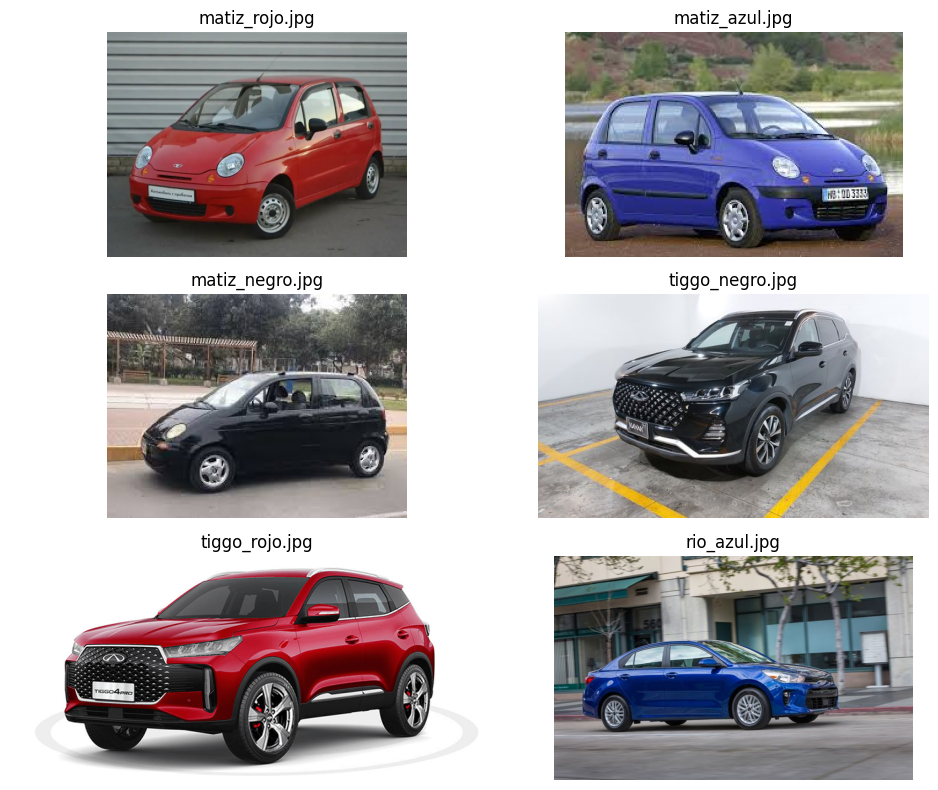

In [71]:
test_images = [
    'matiz_rojo.jpg',
    'matiz_azul.jpg',
    'matiz_negro.jpg',
    'tiggo_negro.jpg',
    'tiggo_rojo.jpg',
    'rio_azul.jpg',
]

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, test_images):
    img_bgr = cv2.imread(img_path)

    if img_bgr is None:
        ax.axis('off')
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(img_path)
    ax.axis('off')

plt.tight_layout()
plt.show()


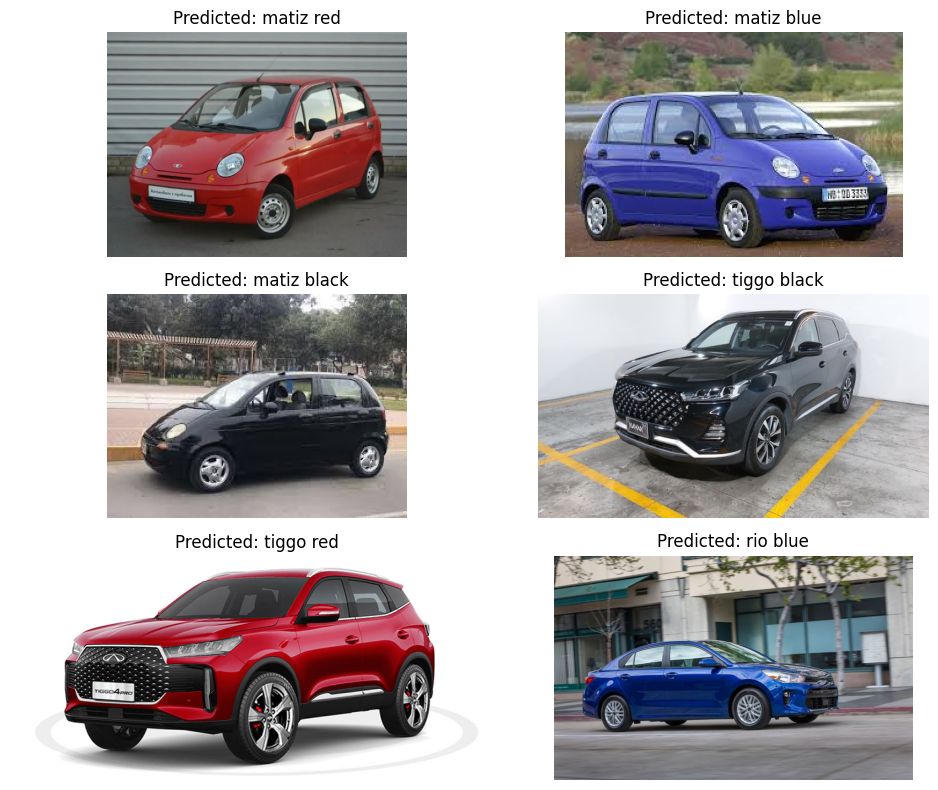

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = os.path.join(
    base_path,
    "checkpoints",
    "car_classifier_best-v3.ckpt"
)

model = CnnModel.load_from_checkpoint(
    ckpt_path,
    model=resnet_model,
    learning_rate=1e-4,
    num_classes=num_classes,
)

model.to(device)
model.eval()

images_rgb = []
predictions = []

for img_path in test_images:
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_pil = Image.fromarray(img_rgb)
    x = image_transforms(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    images_rgb.append(img_rgb)
    predictions.append(pred)

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, img, pred in zip(axes, images_rgb, predictions):
    ax.imshow(img)
    ax.set_title(f"Predicted: {classes[pred]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Conclusión

Los resultados obtenidos en las pruebas con imágenes nuevas fueron bastante buenos, aunque no debería sorprendernos demasiado, ya que al observar las métricas del entrenamiento se aprecia que las gráficas se comportan de manera similar a lo esperado. Si bien en algunos momentos se presentan picos ligeramente más altos o variaciones en el desempeño, estos no representan un problema significativo ni son motivo de preocupación.

Por otra parte, en las pruebas realizadas con el dataset se obtuvo un accuracy bastante positivo, superior al 90 %, lo cual indica que el modelo presenta un desempeño muy bueno.

Para lograr este resultado fue indispensable realizar fine-tuning mediante el ajuste de los pesos del modelo, ya que sin este proceso el accuracy era considerablemente más bajo, rondando el 50 %.

Y finalmente, las pruebas realizadas con imágenes descargadas de internet fueron un rotundo éxito, clasificando correctamente cada una de las imágenes en su respectiva clase. Se observa que, a pesar de la variedad de coches utilizada, el modelo logró dar la respuesta correcta en todos los casos.